# Data Investigator Exercise.  May 2026 - Part 2
#### The Netherlands Organisation for Applied Scientific Research (NLOG) maintains a public register of all oil and gas boreholes drilled in the Netherlands and its continental shelf.

#### As part of the new project on abandoned oil and gas wells in Europe, Global Witness is exploring how datasets like this can be used to identify environmental risks, human impacts, financial liabilities and accountability gaps.

#### **Approach:** First, analyse and filter the NLOG dataset to isolate boreholes of concern (abandoned, suspended and closed-in). Then cross-reference their locations against a database of protected drinking water zones to assess potential environmental risk.

#### This file cross-references the locations of abandoned oil and gas boreholes with drinking water protection zones to determine how many are situated within or near these areas. 

#### **Disclosure:** I used Claude Code to assist with writing part of the code for this analysis.                                               

## Data sources                                                               
* Boreholes — Filtered in [Part 1: Data preparation](netherlands-boreholes-analysis.ipynb)   
* Drinking Water protection zones: [PDOK, official geospatial information platform of the Netherlands government.](https://service.pdok.nl/provincies/grondwaterbeschermingsgebieden/atom/am-gwbg.xml)
    * [Copy of the same file (downloaded on 30 May 2026.](https://raw.githubusercontent.com/FUranga/netherlands-wells-water-zones/refs/heads/main/data/water_protection_zones.gml)



#### **Prerequisites:** This notebook requires `geopandas` and `pyogrio`. Run     
  `!pip install geopandas pyogrio` before executing the cells below.

In [1]:
  #Import libraries                                                             
  import geopandas as gpd                                                     
  import pandas as pd                                                           
  from shapely.geometry import Point

In [2]:
#Open geodata file
water_zones = gpd.read_file("data/water_protection_zones.gml", engine="pyogrio")    
water_zones.head()  

Skipping field text: unsupported OGR type: 5


,gml_id,localId,namespace,language,nativeness,nameStatus,sourceOfName,pronunciation,script,designationPeriod,...,officialDocumentNumber,dateEnteredIntoForce,dateRepealed,officialJournalIdentification,beginPosition,endPosition,legalBasis|LegislationCitation|date|CI_Date|date|Date,CI_DateTypeCode,link_,geometry
0,nlam-gwbg.AC7AB094-C1EE-4049-A9CC-1998A191EF25,AC7AB094-C1EE-4049-A9CC-1998A191EF25,nlam-gwbg,nld,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4030443.073 3380123.424, 4030451.406..."
1,nlam-gwbg.EB6CA936-EEAC-44A1-8A62-9140C42F410D,EB6CA936-EEAC-44A1-8A62-9140C42F410D,nlam-gwbg,nld,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4030951.559 3322459.277, 4030945.724..."
2,nlam-gwbg.BDFC7DEF-5B73-46DA-99BF-DF4BBFAB6E5C,BDFC7DEF-5B73-46DA-99BF-DF4BBFAB6E5C,nlam-gwbg,nld,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4065493.130 3380944.297, 4065494.192..."
3,nlam-gwbg.07A13BA3-EB7B-4437-A87E-11F3287AFB9E,07A13BA3-EB7B-4437-A87E-11F3287AFB9E,nlam-gwbg,nld,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4003011.986 3374266.891, 4002956.606..."
4,nlam-gwbg.431E9D78-4217-49BA-93D3-7FF36C95CBEF,431E9D78-4217-49BA-93D3-7FF36C95CBEF,nlam-gwbg,nld,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((4073127.197 3321019.922, 4073092.479..."


In [3]:
#Open boreholes filtered data file
boreholes = pd.read_csv("data/nlog-boreholes-filtered.csv") 

 ## Methodology
  * A 1km buffer was applied around groundwater protection zones as a proximity 
  threshold for this analysis. 
  * Abandoned, suspended and closed-in oil and gas wells may pose risks of methane or hydrocarbon leakage into groundwater.
  * Borehole coordinates (ED50, EPSG:4230) and water protection zones (EPSG:3035) were both reprojected to RD New (EPSG:28992), a metric coordinate system, so that the 1km buffer could be measured accurately in metres. 

In [4]:
#Create borehole geometry and reproject both datasets to RD New (EPSG:28992) for spatial analysis (assisted with Claude Code)                                                         
geometry = [Point(lon, lat) for lon, lat in zip(boreholes["longitude"], boreholes["latitude"])]
boreholes_gdf = gpd.GeoDataFrame(boreholes, geometry=geometry, crs="EPSG:4230")                                                              
boreholes_gdf = boreholes_gdf.to_crs(epsg=28992)
water_zones = water_zones.to_crs(epsg=28992)

In [5]:
# Which boreholes fall inside a water protection zone? (assisted with Claude Code)                                                         
within = gpd.sjoin(boreholes_gdf, water_zones, predicate="within")            
boreholes_gdf["within_zone"] = boreholes_gdf.index.isin(within.index)

# Which boreholes fall within 1km of a water protection zone?          
zones_1km = water_zones.copy()                                                
zones_1km["geometry"] = zones_1km.geometry.buffer(1000)                       
within_1km = gpd.sjoin(boreholes_gdf, zones_1km, predicate="within")          
boreholes_gdf["within_1km"] = boreholes_gdf.index.isin(within_1km.index)    

# Which boreholes fall outside 1km of a water protection zone?          

boreholes_gdf["outside"] = ~boreholes_gdf["within_1km"]
boreholes_gdf.head()


,On offshore,Province name,Municipality name,longitude,latitude,Type,Status,Result,Current owner,Operator,oil or gas?,Year,geometry,within_zone,within_1km,outside
0,ON,Gelderland,Lingewaard,5.910543,51.929464,Exploration hydrocarbon,Plugged and abandoned,Oil,Nederlandse Aardolie Maatschappij B.V.,Erdöl Niederlande,Y,1944,POINT (190908.714 437930.140),False,False,True
1,ON,Friesland,Smallingerland,5.985471,53.123065,Exploration hydrocarbon,Plugged and abandoned,Gas,Chevron International Oil Company B.V.,American Overseas Petroleum Limited,Y,1965,POINT (194964.262 570782.413),False,False,True
2,ON,Friesland,Boarnsterhim,5.823567,53.076598,Appraisal hydrocarbon,Plugged and abandoned,Gas and oil shows,Chevron International Oil Company B.V.,American Overseas Petroleum Limited,Y,1965,POINT (184156.648 565533.408),False,False,True
3,ON,Friesland,Smallingerland,6.023991,53.095403,Exploration,Plugged and abandoned,Gas,Chevron International Oil Company B.V.,American Overseas Petroleum Limited,Y,1965,POINT (197570.213 567726.068),False,False,True
4,ON,Friesland,Smallingerland,5.912448,53.082830,Appraisal hydrocarbon,Plugged and abandoned,Gas,Chevron International Oil Company B.V.,American Overseas Petroleum Limited,Y,1965,POINT (190108.281 566266.615),False,False,True


In [6]:
#How many abandoned boreholes are there near water zones, by province?
#Inside: wells located within a water protection zone                         
#Within_1km: wells within 1km of a zone but not inside it
boreholes_gdf["only_1km"] = boreholes_gdf["within_1km"] & ~boreholes_gdf["within_zone"]                                                 
                               
summary = boreholes_gdf.fillna({"Province name": "Unknown"}).groupby("Province name").agg(                                                                  
      Inside=("within_zone", "sum"),                                          
      Within_1km=("only_1km", "sum"),                                           
      Outside=("outside", "sum"),    
      Total=("outside", "count")                                              
).astype(int)                 
total_row = pd.DataFrame(summary.sum()).T                                     
total_row.index = ["Total"]              
summary = pd.concat([summary, total_row])                                     
summary['%_Inside'] = (summary['Inside'] / summary['Total'] * 100).round(1)
summary['%_Within_1km'] = (summary['Within_1km'] / summary['Total'] *  100).round(1)                                                                 
summary['%_Outside'] = (summary['Outside'] / summary['Total'] * 100).round(1)
summary                                                                       
                                 

,Inside,Within_1km,Outside,Total,%_Inside,%_Within_1km,%_Outside
Drenthe,37,18,735,790,4.7,2.3,93.0
Flevoland,0,0,3,3,0.0,0.0,100.0
Friesland,4,4,141,149,2.7,2.7,94.6
Gelderland,0,1,4,5,0.0,20.0,80.0
Groningen,0,0,381,381,0.0,0.0,100.0
Noord-Brabant,0,2,16,18,0.0,11.1,88.9
Noord-Holland,2,0,46,48,4.2,0.0,95.8
Overijssel,0,2,58,60,0.0,3.3,96.7
Unknown,0,0,19,19,0.0,0.0,100.0
Zuid-Holland,87,59,259,405,21.5,14.6,64.0


In [7]:
 #Which company own the most wells near or inside water protection zones?    
near = boreholes_gdf[boreholes_gdf['within_1km']].copy()                      
owners = near.groupby('Current owner').size().reset_index(name='Wells near water zones')                                                                 
owners = owners.sort_values('Wells near water zones', ascending=False)        
owners['%'] = (owners['Wells near water zones'] / owners['Wells near water zones'].sum() * 100).round(1)                                                 
owners        

,Current owner,Wells near water zones,%
4,Nederlandse Aardolie Maatschappij B.V.,203,94.0
7,Vermilion Energy Netherlands B.V.,7,3.2
0,Amoco Netherlands Petroleum Company,1,0.5
1,British Petroleum Exploratie Maatschappij Nede...,1,0.5
2,Clyde Petroleum Exploratie B.V.,1,0.5
3,Elf Petroland B.V.,1,0.5
5,Rijksoverheid,1,0.5
6,TAQA Offshore B.V.,1,0.5


In [8]:
#Breakdown by year                                                            
summary_year = boreholes_gdf.groupby("Year").agg(                             
    Inside=("within_zone", "sum"),                        
    Within_1km=("only_1km", "sum"),                                         
    Outside=("outside", "sum"),                                               
    Total=("outside", "count")
).astype(int)                                                                 
total_row = pd.DataFrame(summary_year.sum()).T            
total_row.index = ["Total"]                                                 
summary_year = pd.concat([summary_year, total_row])
summary_year['%_near'] = ((summary_year['Inside'] +                           
summary_year['Within_1km']) / summary_year['Total'] * 100).round(1)
summary_year                                                                  
                                                            

,Inside,Within_1km,Outside,Total,%_near
1921,0,1,0,1,100.0
1938,0,0,1,1,0.0
1942,0,0,1,1,0.0
1943,0,0,2,2,0.0
1944,0,0,3,3,0.0
...,...,...,...,...,...
2018,0,0,1,1,0.0
2019,0,0,1,1,0.0
2020,0,0,1,1,0.0
2021,0,0,1,1,0.0


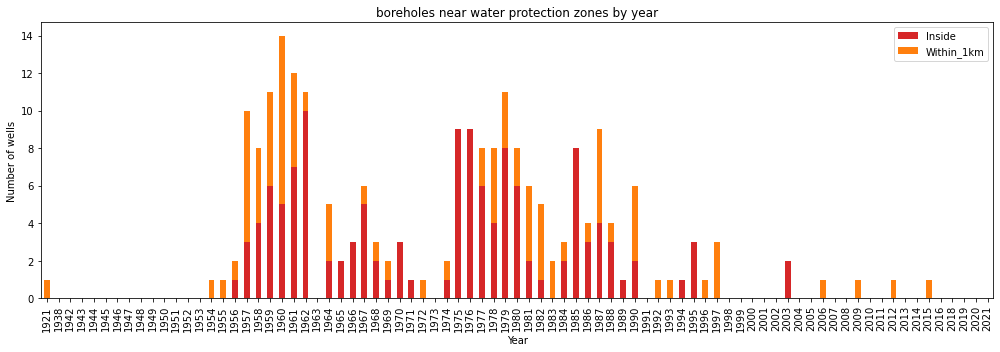

In [11]:
#Chart annual evolution
import matplotlib.pyplot as plt                                               
fig, ax = plt.subplots(figsize=(14, 5))                                       
summary_year_plot = summary_year.drop("Total")                                
summary_year_plot[["Inside", "Within_1km"]].plot.bar(stacked=True, ax=ax,
color=["#d62728", "#ff7f0e"])                                                 
                                                            
ax.set_title("boreholes near water protection zones by year")                     
ax.set_ylabel("Number of wells")                          
ax.set_xlabel("Year")                                                         
plt.tight_layout()
plt.show()                                                                                          

In [17]:
#Export all boreholes near water zones for Datawrapper map                        
near_boreholes = boreholes_gdf[boreholes_gdf['within_zone'] |                     
boreholes_gdf['within_1km']].copy()                                           
near_boreholes = near_boreholes.to_crs(epsg=4326)                                     
near_boreholes["longitude"] = near_boreholes.geometry.x                               
near_boreholes["latitude"] = near_boreholes.geometry.y                              
near_boreholes = near_boreholes.drop(columns=["geometry"])                            
near_boreholes.to_csv("boreholes_for_map_near.csv", index=False)                  

In [21]:
  #Export province data for Datawrapper stacked bar chart                       
  summary_prov = summary.drop("Total")                                          
  summary_prov = summary_prov[["Inside", "Within_1km", "Outside"]].copy()       
  summary_prov = summary_prov.sort_values("Inside", ascending=False)            
  summary_prov.to_csv("chart_provinces.csv")                                    
  summary_prov 

,Inside,Within_1km,Outside
Zuid-Holland,87,59,259
Drenthe,37,18,735
Friesland,4,4,141
Noord-Holland,2,0,46
Flevoland,0,0,3
Gelderland,0,1,4
Groningen,0,0,381
Noord-Brabant,0,2,16
Overijssel,0,2,58
Unknown,0,0,19
